<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW4/HW4_Seq2Seq_Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW4

https://github.com/JordanTerwilliger/Intro-to-Deep-Learning

#Imports

In [1]:
import torch
import torch.nn as nn
import torch.functional as F

import matplotlib.pyplot as plt
import numpy as np

import requests

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torch import optim

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
url = "https://raw.githubusercontent.com/JordanTerwilliger/Intro-to-Deep-Learning/refs/heads/main/HW3/vast_english_french.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

#Preprocessing

In [2]:
def tokenize_and_pad(sentences, vocab):
    # Calculate the maximum sentence length for padding
    max_length = max(len(sentence.split(' ')) for sentence in sentences) + 2  # +2 for SOS and EOS tokens
    tokenized_sentences = []
    for sentence in sentences:
        # Convert each sentence to a list of indices, adding SOS and EOS tokens
        tokens = [vocab.word2index["<SOS>"]] + [vocab.word2index[word] for word in sentence.split(' ')] + [vocab.word2index["<EOS>"]]
        # Pad sentences to the maximum length
        padded_tokens = tokens + [vocab.word2index["<PAD>"]] * (max_length - len(tokens))
        tokenized_sentences.append(padded_tokens)
    return torch.tensor(tokenized_sentences, dtype=torch.long)

# Vocabulary class to handle mapping between words and numerical indices
class Vocabulary:
  def __init__(self):
    #Dictionaries for special tokens and reverse
    self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
    self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
    self.word_count = {}  # Keep track of word frequencies
    self.n_words = 3  # Start counting from 3 to account for special tokens

  def add_sentence(self, sentence):
    # Add all words in a sentence to the vocabulary
    for word in sentence.split(' '):
      self.add_word(word)

  def add_word(self, word):
        # Add a word to the vocabulary
        if word not in self.word2index:
            # Assign a new index to the word and update mappings
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            # Increment word count if the word already exists in the vocabulary
            self.word_count[word] += 1

class EngFrDataset(Dataset):
    def __init__(self, pairs):
        self.eng_vocab = Vocabulary()
        self.fr_vocab = Vocabulary()
        self.pairs = []

        # Process each English-French pair
        for eng, fr in pairs:
            self.eng_vocab.add_sentence(eng)
            self.fr_vocab.add_sentence(fr)
            self.pairs.append((eng, fr))

        # Separate English and French sentences
        self.eng_sentences = [pair[0] for pair in self.pairs]
        self.fr_sentences = [pair[1] for pair in self.pairs]

        # Tokenize and pad sentences
        self.eng_tokens = tokenize_and_pad(self.eng_sentences, self.eng_vocab)
        self.fr_tokens = tokenize_and_pad(self.fr_sentences, self.fr_vocab)

    def __len__(self):
        # Return the number of sentence pairs
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get the tokenized and padded sentences by index
        eng_tokens = self.eng_tokens[idx]
        fr_tokens = self.fr_tokens[idx]
        return eng_tokens, fr_tokens

In [3]:
pairs = [
    tuple(part.strip() for part in line.split('\t')) for line in text.splitlines() if '\t' in line
]

dataset = EngFrDataset(pairs)

train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(1))

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
idx2w_e = dataset.eng_vocab.index2word
idx2w_f = dataset.fr_vocab.index2word
print(idx2w_e)
print(idx2w_f)
batch_size = 256
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: 'I', 4: 'am', 5: 'cold', 6: 'You', 7: 'are', 8: 'tired', 9: 'He', 10: 'is', 11: 'hungry', 12: 'She', 13: 'happy', 14: 'We', 15: 'friends', 16: 'They', 17: 'students', 18: 'The', 19: 'cat', 20: 'sleeping', 21: 'sun', 22: 'shining', 23: 'love', 24: 'music', 25: 'speaks', 26: 'French', 27: 'fluently', 28: 'enjoys', 29: 'reading', 30: 'books', 31: 'play', 32: 'soccer', 33: 'every', 34: 'weekend', 35: 'movie', 36: 'starts', 37: 'at', 38: '7', 39: 'PM', 40: 'wears', 41: 'a', 42: 'red', 43: 'dress', 44: 'cook', 45: 'dinner', 46: 'together', 47: 'drives', 48: 'blue', 49: 'car', 50: 'visit', 51: 'museums', 52: 'often', 53: 'restaurant', 54: 'serves', 55: 'delicious', 56: 'food', 57: 'studies', 58: 'mathematics', 59: 'university', 60: 'watch', 61: 'movies', 62: 'on', 63: 'Fridays', 64: 'listens', 65: 'to', 66: 'while', 67: 'jogging', 68: 'travel', 69: 'around', 70: 'the', 71: 'world', 72: 'book', 73: 'table', 74: 'dances', 75: 'gracefully', 76: 'celebrate'

#Model Creation

In [4]:
#d_model = hidden_size
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

#Create Model
class TransformerModel(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, nhead, num_layers):
    super(TransformerModel, self).__init__()

    self.source_embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)
    self.target_embedding = nn.Embedding(output_size, hidden_size, padding_idx=0) #PAD = 0

    self.pos_encoder = PositionalEncoding(hidden_size)

    encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, batch_first = True)
    self.encoder = nn.TransformerEncoder(encoder_layers, num_layers)

    decoder_layers = nn.TransformerDecoderLayer(hidden_size, nhead, batch_first=True)
    self.decoder = nn.TransformerDecoder(decoder_layers, num_layers)

    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, source, target):
    source_embedded = self.pos_encoder(self.source_embedding(source))
    target_embedded = self.pos_encoder(self.target_embedding(target))

    encoder_output = self.encoder(source_embedded)

    tgt_len = target.size(1)
    causal_mask = torch.triu(
        torch.full((tgt_len, tgt_len), float('-inf'), device=target.device),
        diagonal=1
    )

    decoder_output = self.decoder(target_embedded, encoder_output, tgt_mask=causal_mask)
    return self.fc(decoder_output)

  @torch.no_grad()
  def greedy_decode(self, source, max_len, sos_idx=1, eos_idx=2):
    self.eval()
    source_embedded = self.pos_encoder(self.source_embedding(source))
    encoder_output = self.encoder(source_embedded)

    batch_size = source.size(0)
    ys = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=source.device)

    for _ in range(max_len - 1):
        target_embedded = self.pos_encoder(self.target_embedding(ys))
        tgt_len = ys.size(1)
        causal_mask = torch.triu(
            torch.full((tgt_len, tgt_len), float('-inf'), device=source.device),
            diagonal=1
        )
        decoder_output = self.decoder(target_embedded, encoder_output, tgt_mask=causal_mask)
        next_token_logits = self.fc(decoder_output[:, -1, :])
        next_token = next_token_logits.argmax(-1, keepdim=True)
        ys = torch.cat([ys, next_token], dim=1)
        if (next_token == eos_idx).all():
            break
    return ys

In [5]:
def createPlot(train_loss_list, val_loss_list, val_accuracy_list):
  import matplotlib.pyplot as plt
  plt.figure(figsize=(10, 6))
  plt.plot(train_loss_list, label='Training Loss')
  plt.plot(val_loss_list, label='Validation Loss')
  plt.title('Training and Validation Loss Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

In [6]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def BLEU(model, dataloader, n_examples=5, max_gen_length=20, sos_idx=1, eos_idx=2, pad_idx=0):
  total_bleu_score = 0.0
  total_sentences = 0
  chencherry = SmoothingFunction()
  examples_printed = 0

  # Ensure model is in evaluation mode
  model.eval()

  idx2w_e = dataset.eng_vocab.index2word
  idx2w_f = dataset.fr_vocab.index2word

  with torch.no_grad():
    for target_tensor, input_tensor in dataloader:
      input_tensor = input_tensor.to(device)
      target_tensor = target_tensor.to(device)

      batch_size = input_tensor.size(0)

      # 1. Pass entire batch through Encoder
      source_embedded = model.pos_encoder(model.source_embedding(input_tensor))
      encoder_output = model.encoder(source_embedded)

      # 2. Setup Decoder for the batch
      decoder_input = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=device)

      # Tensor to store predictions for the whole batch: [batch_size, max_gen_length]
      batch_predictions = torch.zeros(batch_size, max_gen_length, dtype=torch.long, device=device)

      # 3. Generate step (autoregressive, one token at a time for the whole batch)
      for di in range(max_gen_length):
          target_embedded = model.pos_encoder(model.target_embedding(decoder_input))
          tgt_len = decoder_input.size(1)
          causal_mask = torch.triu(
              torch.full((tgt_len, tgt_len), float('-inf'), device=device),
              diagonal=1
          )
          decoder_output = model.decoder(target_embedded, encoder_output, tgt_mask=causal_mask)
          logits = model.fc(decoder_output[:, -1, :])  # only need the newest step
          _, topi = logits.topk(1)  # topi shape: [batch_size, 1]

          # Store the predicted token for each sequence in the batch
          batch_predictions[:, di] = topi.squeeze(1)

          # Feed predictions back in as the next decoder input
          decoder_input = torch.cat([decoder_input, topi.detach()], dim=1)

      # 4. Convert to strings and calculate BLEU for each sentence in the batch
      for b in range(batch_size):
        inp_seq = input_tensor[b]
        tgt_seq = target_tensor[b]
        pred_seq = batch_predictions[b]

        # Helper function to convert indices to strings properly
        def to_string(seq, vocab, is_pred=False):
            words = []
            for idx in seq:
                val = idx.item()
                # For predictions, we MUST stop at the first EOS token
                if val == eos_idx and is_pred:
                    break
                # Ignore special tokens in the final readable string
                if val not in (sos_idx, eos_idx, pad_idx):
                    words.append(vocab[val])
            return ' '.join(words)

        input_string = to_string(inp_seq, idx2w_f)
        target_string = to_string(tgt_seq, idx2w_e)
        predicted_string = to_string(pred_seq, idx2w_e, is_pred=True)

        # --- EVALUATION: BLEU Score ---
        reference_tokens = [target_string.split()]
        candidate_tokens = predicted_string.split()

        bleu = sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=chencherry.method1)
        total_bleu_score += bleu
        total_sentences += 1

        # Print the first n_examples
        if examples_printed < n_examples:
          match_status = "PASS" if predicted_string == target_string else "FAIL"
          print(f'Input: {input_string:<20} | Target: {target_string:<20} | Predicted: {predicted_string:<20} | Match: {match_status:<4} | BLEU: {bleu:.4f}')
          examples_printed += 1

  # Calculate average across all processed sentences
  average_bleu = total_bleu_score / total_sentences
  print(f'\n -> Average Validation BLEU-4 Score : {average_bleu:.4f}')

  return average_bleu

#1 block, 2 heads

In [7]:
learning_rate = 0.001
input_size = len(dataset.fr_vocab.index2word)
hidden_size = 128
output_size = len(dataset.eng_vocab.index2word)
nhead = 2
num_layers = 1
epochs = 100

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)


Epoch 0, Loss: 2.8666, Val Accuracy: 0.1251, Val Loss: 4.9831
Epoch 1, Loss: 1.2423, Val Accuracy: 0.1251, Val Loss: 4.5912
Epoch 2, Loss: 0.7792, Val Accuracy: 0.1251, Val Loss: 4.3224
Epoch 3, Loss: 0.5568, Val Accuracy: 0.1545, Val Loss: 4.0485
Epoch 4, Loss: 0.4293, Val Accuracy: 0.1545, Val Loss: 3.8400
Epoch 5, Loss: 0.3313, Val Accuracy: 0.1545, Val Loss: 3.6880
Epoch 6, Loss: 0.2646, Val Accuracy: 0.1545, Val Loss: 3.5709
Epoch 7, Loss: 0.2301, Val Accuracy: 0.1545, Val Loss: 3.4740
Epoch 8, Loss: 0.1971, Val Accuracy: 0.1545, Val Loss: 3.3904
Epoch 9, Loss: 0.1723, Val Accuracy: 0.1545, Val Loss: 3.3163
Epoch 10, Loss: 0.1536, Val Accuracy: 0.1545, Val Loss: 3.2546
Epoch 11, Loss: 0.1367, Val Accuracy: 0.1883, Val Loss: 3.1969
Epoch 12, Loss: 0.1232, Val Accuracy: 0.2074, Val Loss: 3.1439
Epoch 13, Loss: 0.1109, Val Accuracy: 0.1917, Val Loss: 3.0990
Epoch 14, Loss: 0.1006, Val Accuracy: 0.1894, Val Loss: 3.0562
Epoch 15, Loss: 0.0928, Val Accuracy: 0.1883, Val Loss: 3.0246
Ep

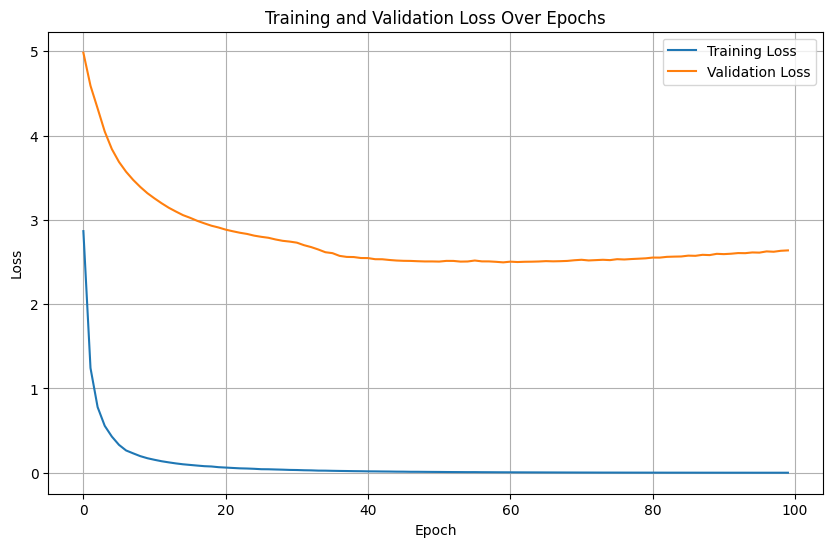

In [8]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [9]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: They built a campfire last | Match: FAIL | BLEU: 0.0523
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: I enjoy walking in the park | Match: FAIL | BLEU: 0.0408
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: He cleans his office desk every single morning | Match: FAIL | BLEU: 0.0366
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: We went for a beautiful | Match: FAIL | BLEU: 0.0440
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The map is difficult to understand | Match: FAIL | BLEU: 0.0408

 -> Average Validation BLEU-4 Score : 0.1484


#1 block ,4 heads

In [10]:
num_layers = 1
nhead = 4

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)

Epoch 0, Loss: 2.7153, Val Accuracy: 0.1251, Val Loss: 4.7397
Epoch 1, Loss: 1.1768, Val Accuracy: 0.1251, Val Loss: 4.4331
Epoch 2, Loss: 0.7521, Val Accuracy: 0.1251, Val Loss: 4.2083
Epoch 3, Loss: 0.5346, Val Accuracy: 0.1545, Val Loss: 3.9578
Epoch 4, Loss: 0.3983, Val Accuracy: 0.1545, Val Loss: 3.7581
Epoch 5, Loss: 0.3251, Val Accuracy: 0.1545, Val Loss: 3.6156
Epoch 6, Loss: 0.2710, Val Accuracy: 0.1545, Val Loss: 3.5120
Epoch 7, Loss: 0.2227, Val Accuracy: 0.1545, Val Loss: 3.4281
Epoch 8, Loss: 0.1947, Val Accuracy: 0.1545, Val Loss: 3.3605
Epoch 9, Loss: 0.1709, Val Accuracy: 0.1826, Val Loss: 3.2903
Epoch 10, Loss: 0.1493, Val Accuracy: 0.1905, Val Loss: 3.2329
Epoch 11, Loss: 0.1351, Val Accuracy: 0.1984, Val Loss: 3.1843
Epoch 12, Loss: 0.1199, Val Accuracy: 0.2097, Val Loss: 3.1276
Epoch 13, Loss: 0.1119, Val Accuracy: 0.2097, Val Loss: 3.0818
Epoch 14, Loss: 0.1002, Val Accuracy: 0.1714, Val Loss: 3.0511
Epoch 15, Loss: 0.0910, Val Accuracy: 0.1860, Val Loss: 3.0153
Ep

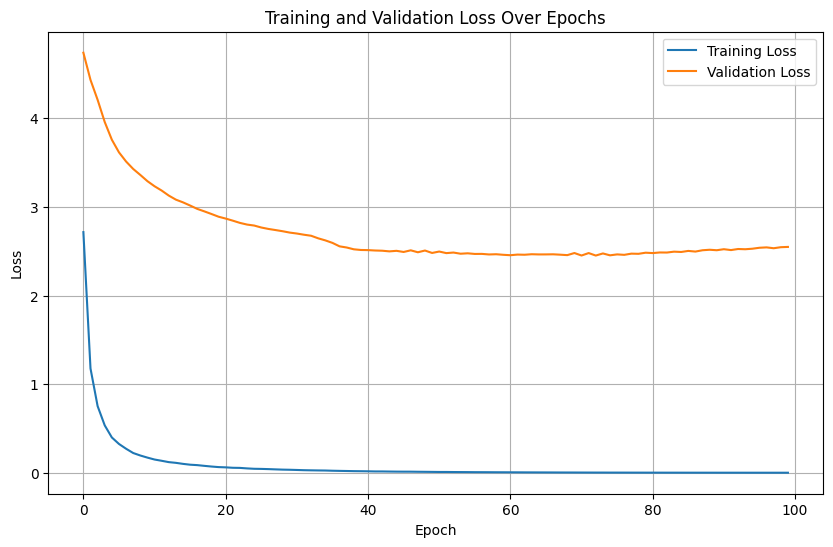

In [11]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [12]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: They are planning a small village | Match: FAIL | BLEU: 0.0955
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: I am reading an      | Match: FAIL | BLEU: 0.0000
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: He likes to read science fiction novels | Match: FAIL | BLEU: 0.0286
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: We are going to buy some organic vegetables | Match: FAIL | BLEU: 0.0278
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The soup is melting quickly | Match: FAIL | BLEU: 0.1136

 -> Average Validation BLEU-4 Score : 0.1824


#2 block ,2 heads

In [13]:
num_layers = 2
nhead = 2

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)

Epoch 0, Loss: 2.7212, Val Accuracy: 0.1251, Val Loss: 4.8025
Epoch 1, Loss: 1.2335, Val Accuracy: 0.1251, Val Loss: 4.5448
Epoch 2, Loss: 0.7748, Val Accuracy: 0.1421, Val Loss: 4.2163
Epoch 3, Loss: 0.5323, Val Accuracy: 0.1545, Val Loss: 3.9502
Epoch 4, Loss: 0.4110, Val Accuracy: 0.1545, Val Loss: 3.7756
Epoch 5, Loss: 0.3161, Val Accuracy: 0.1567, Val Loss: 3.6243
Epoch 6, Loss: 0.2665, Val Accuracy: 0.1736, Val Loss: 3.5151
Epoch 7, Loss: 0.2245, Val Accuracy: 0.1928, Val Loss: 3.4340
Epoch 8, Loss: 0.1993, Val Accuracy: 0.1973, Val Loss: 3.3673
Epoch 9, Loss: 0.1702, Val Accuracy: 0.1950, Val Loss: 3.2996
Epoch 10, Loss: 0.1551, Val Accuracy: 0.1973, Val Loss: 3.2420
Epoch 11, Loss: 0.1375, Val Accuracy: 0.2108, Val Loss: 3.1868
Epoch 12, Loss: 0.1235, Val Accuracy: 0.1871, Val Loss: 3.1347
Epoch 13, Loss: 0.1093, Val Accuracy: 0.1883, Val Loss: 3.0866
Epoch 14, Loss: 0.1008, Val Accuracy: 0.1973, Val Loss: 3.0502
Epoch 15, Loss: 0.0896, Val Accuracy: 0.1883, Val Loss: 3.0065
Ep

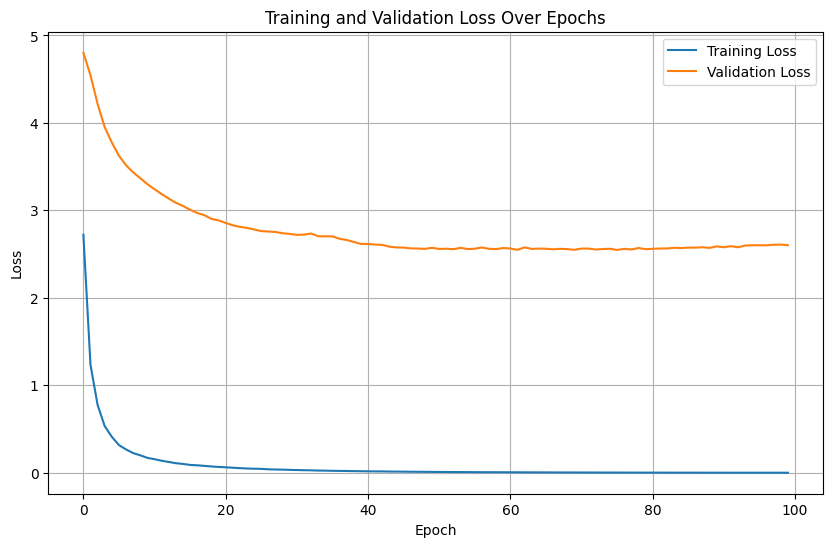

In [14]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [15]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: They listen to classical music | Match: FAIL | BLEU: 0.0440
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: I love this song     | Match: FAIL | BLEU: 0.0000
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: He practices yoga every morning | Match: FAIL | BLEU: 0.0690
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: We walk through the historic streets of Paris | Match: FAIL | BLEU: 0.0278
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The library is a quiet place | Match: FAIL | BLEU: 0.0408

 -> Average Validation BLEU-4 Score : 0.1702


#2 block ,4 heads

In [16]:
num_layers = 2
nhead = 4
epochs = 20

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)

Epoch 0, Loss: 2.6663, Val Accuracy: 0.1251, Val Loss: 4.7403
Epoch 1, Loss: 1.2115, Val Accuracy: 0.1251, Val Loss: 4.5341
Epoch 2, Loss: 0.7632, Val Accuracy: 0.1251, Val Loss: 4.2811
Epoch 3, Loss: 0.5466, Val Accuracy: 0.1251, Val Loss: 3.9664
Epoch 4, Loss: 0.4072, Val Accuracy: 0.1545, Val Loss: 3.7824
Epoch 5, Loss: 0.3284, Val Accuracy: 0.1545, Val Loss: 3.6541
Epoch 6, Loss: 0.2765, Val Accuracy: 0.1545, Val Loss: 3.5389
Epoch 7, Loss: 0.2323, Val Accuracy: 0.1251, Val Loss: 3.4573
Epoch 8, Loss: 0.1949, Val Accuracy: 0.1793, Val Loss: 3.3844
Epoch 9, Loss: 0.1732, Val Accuracy: 0.1950, Val Loss: 3.3202
Epoch 10, Loss: 0.1558, Val Accuracy: 0.2041, Val Loss: 3.2685
Epoch 11, Loss: 0.1413, Val Accuracy: 0.2108, Val Loss: 3.2171
Epoch 12, Loss: 0.1250, Val Accuracy: 0.2097, Val Loss: 3.1684
Epoch 13, Loss: 0.1101, Val Accuracy: 0.2018, Val Loss: 3.1166
Epoch 14, Loss: 0.1031, Val Accuracy: 0.2018, Val Loss: 3.0815
Epoch 15, Loss: 0.0909, Val Accuracy: 0.2018, Val Loss: 3.0251
Ep

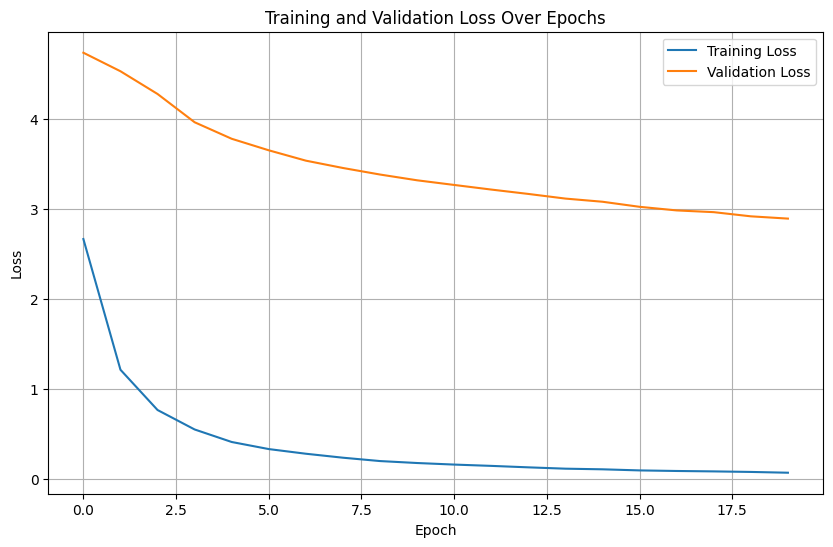

In [17]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [18]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: The She is very to the beach | Match: FAIL | BLEU: 0.0000
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: The She is very to the beach | Match: FAIL | BLEU: 0.0330
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: The She is very to the beach | Match: FAIL | BLEU: 0.0000
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: The She is very to the beach | Match: FAIL | BLEU: 0.0000
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The She is very to the beach | Match: FAIL | BLEU: 0.0330

 -> Average Validation BLEU-4 Score : 0.0281


#4 block ,2 heads

In [19]:
num_layers = 4
nhead = 2
model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)

Epoch 0, Loss: 2.7898, Val Accuracy: 0.1251, Val Loss: 4.9931
Epoch 1, Loss: 1.2819, Val Accuracy: 0.1251, Val Loss: 4.8151
Epoch 2, Loss: 0.8290, Val Accuracy: 0.1251, Val Loss: 4.6505
Epoch 3, Loss: 0.6001, Val Accuracy: 0.1251, Val Loss: 4.4639
Epoch 4, Loss: 0.4515, Val Accuracy: 0.1251, Val Loss: 4.1360
Epoch 5, Loss: 0.3509, Val Accuracy: 0.1421, Val Loss: 3.9139
Epoch 6, Loss: 0.2863, Val Accuracy: 0.1251, Val Loss: 3.7489
Epoch 7, Loss: 0.2476, Val Accuracy: 0.1545, Val Loss: 3.6507
Epoch 8, Loss: 0.2076, Val Accuracy: 0.1545, Val Loss: 3.5836
Epoch 9, Loss: 0.1873, Val Accuracy: 0.1545, Val Loss: 3.4754
Epoch 10, Loss: 0.1725, Val Accuracy: 0.1545, Val Loss: 3.4489
Epoch 11, Loss: 0.1506, Val Accuracy: 0.2052, Val Loss: 3.4468
Epoch 12, Loss: 0.1354, Val Accuracy: 0.1545, Val Loss: 3.3851
Epoch 13, Loss: 0.1252, Val Accuracy: 0.1702, Val Loss: 3.3367
Epoch 14, Loss: 0.1114, Val Accuracy: 0.1917, Val Loss: 3.3112
Epoch 15, Loss: 0.1061, Val Accuracy: 0.1702, Val Loss: 3.2869
Ep

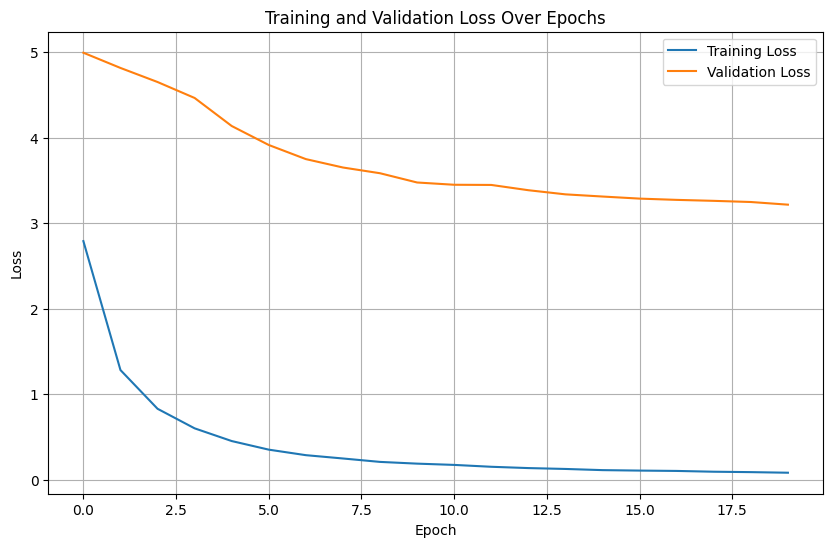

In [20]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [21]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: The a a a the        | Match: FAIL | BLEU: 0.0440
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: The a a a the        | Match: FAIL | BLEU: 0.0537
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: The a a a the        | Match: FAIL | BLEU: 0.0000
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: The a a a the        | Match: FAIL | BLEU: 0.0000
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The a a a the        | Match: FAIL | BLEU: 0.0537

 -> Average Validation BLEU-4 Score : 0.0295


#4 block ,4 heads

In [22]:
num_layers = 4
nhead = 4

model = TransformerModel(input_size, output_size, hidden_size, nhead, num_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # ignore padding (index 0)

Epoch 0, Loss: 2.7122, Val Accuracy: 0.1251, Val Loss: 4.9612
Epoch 1, Loss: 1.2802, Val Accuracy: 0.1251, Val Loss: 4.8015
Epoch 2, Loss: 0.8255, Val Accuracy: 0.1251, Val Loss: 4.6589
Epoch 3, Loss: 0.6052, Val Accuracy: 0.1251, Val Loss: 4.5287
Epoch 4, Loss: 0.4667, Val Accuracy: 0.1251, Val Loss: 4.4082
Epoch 5, Loss: 0.3747, Val Accuracy: 0.1251, Val Loss: 4.2208
Epoch 6, Loss: 0.3095, Val Accuracy: 0.1251, Val Loss: 3.9004
Epoch 7, Loss: 0.2431, Val Accuracy: 0.1251, Val Loss: 3.7545
Epoch 8, Loss: 0.2190, Val Accuracy: 0.1251, Val Loss: 3.6711
Epoch 9, Loss: 0.1949, Val Accuracy: 0.1251, Val Loss: 3.6284
Epoch 10, Loss: 0.1741, Val Accuracy: 0.1545, Val Loss: 3.5710
Epoch 11, Loss: 0.1533, Val Accuracy: 0.1545, Val Loss: 3.4949
Epoch 12, Loss: 0.1382, Val Accuracy: 0.1601, Val Loss: 3.4531
Epoch 13, Loss: 0.1283, Val Accuracy: 0.1702, Val Loss: 3.4170
Epoch 14, Loss: 0.1178, Val Accuracy: 0.1815, Val Loss: 3.4015
Epoch 15, Loss: 0.1110, Val Accuracy: 0.1973, Val Loss: 3.4254
Ep

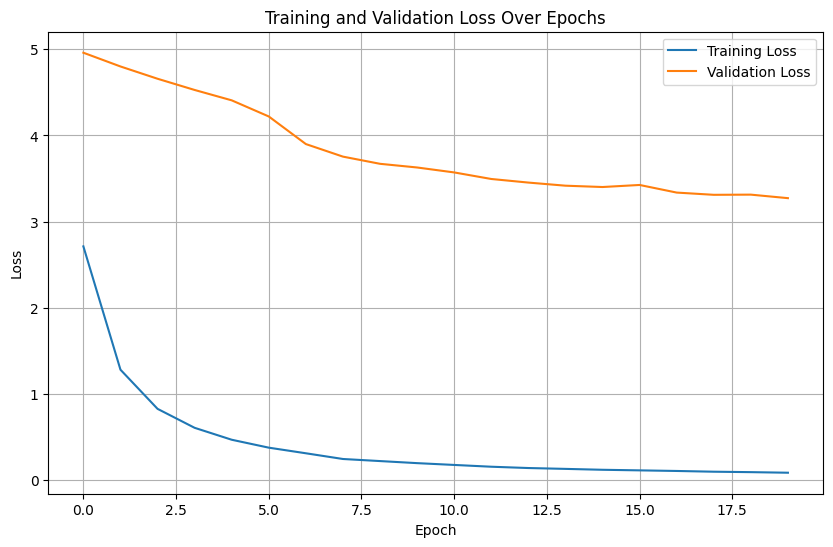

In [23]:
#Training Loop
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
train_batches = 0

for epoch in range(epochs):
  model.train()
  for y_train, X_train in train_loader:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    epoch_train_loss = 0.0

    optimizer.zero_grad()

    # Bug 2 fix: shift target — decoder sees <SOS>...wN-1, predicts w1...<EOS>
    tgt_input = y_train[:, :-1]
    tgt_output = y_train[:, 1:]

    y_pred = model(X_train, tgt_input)  # Forward pass

    # Bug 1 fix: flatten batch+seq for CrossEntropyLoss
    loss = criterion(y_pred.reshape(-1, y_pred.size(-1)), tgt_output.reshape(-1))

    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

    epoch_train_loss += loss.item()
    train_batches += 1


# Validation Loop
  model.eval()

  total_val_loss = 0.0
  total_val_acc = 0.0
  val_batches = 0

  with torch.no_grad():
    for y_test, X_test in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      # Teacher-forced loss (for comparable loss curve — model still sees ground truth here)
      tgt_input_val = y_test[:, :-1]
      tgt_output_val = y_test[:, 1:]
      val_output = model(X_test, tgt_input_val)
      val_loss = criterion(val_output.reshape(-1, val_output.size(-1)), tgt_output_val.reshape(-1))

      # Bug 3 fix: real accuracy needs autoregressive generation, not teacher forcing
      generated = model.greedy_decode(X_test, max_len=y_test.size(1))
      # Pad/truncate generated to match y_test length for elementwise comparison
      gen_len = generated.size(1)
      tgt_len = y_test.size(1)
      if gen_len < tgt_len:
        pad = torch.full((generated.size(0), tgt_len - gen_len), PAD_IDX, device=device, dtype=torch.long)
        generated = torch.cat([generated, pad], dim=1)
      else:
        generated = generated[:, :tgt_len]

      mask = (y_test != PAD_IDX)
      correct = ((generated == y_test) & mask).sum().item()
      total = mask.sum().item()
      val_accuracy = correct / total if total > 0 else 0.0

      total_val_loss += val_loss.item()
      total_val_acc += val_accuracy
      val_batches += 1

  avg_train_loss = epoch_train_loss / train_batches
  avg_val_loss = total_val_loss / val_batches
  avg_val_acc = total_val_acc / val_batches

  train_loss_list.append(avg_train_loss)
  val_loss_list.append(avg_val_loss)
  val_accuracy_list.append(avg_val_acc)

  if (epoch % 1 == 0):
    print(f'Epoch {epoch}, Loss: {avg_train_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}, Val Loss: {avg_val_loss:.4f}')
createPlot(train_loss_list, val_loss_list, val_accuracy_list)

In [24]:
avg_bleu = BLEU(model, test_loader, n_examples=5)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: The The a the        | Match: FAIL | BLEU: 0.0487
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: The The a the        | Match: FAIL | BLEU: 0.0803
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: The The a the        | Match: FAIL | BLEU: 0.0000
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: The The a the        | Match: FAIL | BLEU: 0.0000
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The The a the        | Match: FAIL | BLEU: 0.0803

 -> Average Validation BLEU-4 Score : 0.0346
